# Dataset Exploration — Metadati clinici e demografici grezzi

Parte 3 di 3 (vedi anche `dataset_availability.ipynb` e `lesion_quality.ipynb`).

In [9]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path dinamici relativi alla posizione del progetto
project_root = '/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs'
DERIV_ROOT = Path(project_root) / "data" / "clinical_connectome" / "derivatives"


### Utilità di plotting

`dataset_grid(n)` crea una griglia di subplot (righe × colonne, non una singola riga) per confrontare i dataset — usata in tutte le sezioni sotto.

In [10]:
import numpy as np

def dataset_grid(n_items: int, n_cols: int = 3, subplot_size: tuple[float, float] = (4, 4)):
    """Griglia n_rows x n_cols di assi (un subplot per dataset), assi in eccesso nascosti."""
    n_rows = -(-n_items // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(subplot_size[0] * n_cols, subplot_size[1] * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n_items:]:
        ax.set_visible(False)
    return fig, axes[:n_items]


## Metadati clinici e demografici grezzi

Analizza `data/clinical_connectome/metadata_tsv/participants_*.tsv` — un file per dataset, dati clinici/demografici grezzi (non filtrati). Ogni sezione confronta tutti i dataset fianco a fianco, un subplot per dataset.

### Caricamento

In [11]:
METADATA_TSV_DIR = Path(project_root) / "data" / "clinical_connectome" / "metadata_tsv"

TSV_FILES = sorted(METADATA_TSV_DIR.glob("participants_*.tsv"))
PREFIX = "participants_"

# Schema comune ai tsv già normalizzati (vedi tabella "Columns" sotto: age, center_id,
# dataset, disease_id, participant_id, sex sono condivise da tutti i dataset normalizzati).
# Un tsv appena onboardato può non essere ancora stato portato in questo schema (es.
# NEMESIS_T0, solo participant_id/age/sex/group/participant_id_dmp) - va escluso qui
# esplicitamente, non lasciato rompere le celle sotto con un KeyError.
REQUIRED_COLUMNS = {"disease_id", "center_id", "dataset"}

datasets_tsv = {}
skipped_tsv = {}
for f in TSV_FILES:
    name = f.stem[len(PREFIX):]
    df = pd.read_csv(f, sep="\t")
    missing = REQUIRED_COLUMNS - set(df.columns)
    if missing:
        skipped_tsv[name] = missing
    else:
        datasets_tsv[name] = df

print(f"{len(datasets_tsv)} dataset caricati: {list(datasets_tsv.keys())}")
if skipped_tsv:
    print(f"\n⚠️ {len(skipped_tsv)} tsv esclusi (schema non ancora normalizzato):")
    for name, missing in skipped_tsv.items():
        print(f"    - {name}: mancano le colonne {sorted(missing)}")

7 dataset caricati: ['PASPORT', 'PSP', 'UCL', 'UKE', 'UKE_SFB', 'UKLFR', 'WashU']

⚠️ 1 tsv esclusi (schema non ancora normalizzato):
    - NEMESIS_T0: mancano le colonne ['center_id', 'dataset', 'disease_id']


### Columns

In [12]:
all_columns = set()
for df in datasets_tsv.values():
    all_columns |= set(df.columns)

print(f"{len(all_columns)} colonne distinte in totale su {len(datasets_tsv)} dataset\n")
for name, df in datasets_tsv.items():
    print(f"{name}: {len(df.columns)} colonne")


181 colonne distinte in totale su 7 dataset

PASPORT: 16 colonne
PSP: 50 colonne
UCL: 6 colonne
UKE: 84 colonne
UKE_SFB: 38 colonne
UKLFR: 55 colonne
WashU: 38 colonne


Confronto tra i dataset: colonne comuni a tutti, e una tabella colonna × dataset (True/False) per tutte le altre — ordinata da chi è condivisa da più dataset a chi è specifica di uno solo.

In [13]:
cols_by_dataset = {name: set(df.columns) for name, df in datasets_tsv.items()}
all_columns = set().union(*cols_by_dataset.values())
common_columns = set.intersection(*cols_by_dataset.values())
print(f"Colonne comuni a tutti i {len(datasets_tsv)} dataset ({len(common_columns)}): {sorted(common_columns)}\n")

non_common_columns = sorted(all_columns - common_columns)
presence_table = pd.DataFrame(
    {name: [c in cols for c in non_common_columns] for name, cols in cols_by_dataset.items()},
    index=non_common_columns,
)
presence_table = presence_table.loc[presence_table.sum(axis=1).sort_values(ascending=False).index]
display(presence_table)


Colonne comuni a tutti i 7 dataset (6): ['age', 'center_id', 'dataset', 'disease_id', 'participant_id', 'sex']



,PASPORT,PSP,UCL,UKE,UKE_SFB,UKLFR,WashU
disease_notes,True,True,False,True,True,True,True
education,True,True,False,True,True,True,True
NIHSS,False,True,False,True,True,True,True
lesion_side,False,True,False,True,True,True,True
handedness,False,True,False,True,True,True,True
...,...,...,...,...,...,...,...
MOCA_naming,False,False,False,False,False,True,False
MOCA_orientation,False,False,False,False,False,True,False
MOCA_recall,False,False,False,False,False,True,False
MOCA_total,False,False,False,False,False,True,False


In [ ]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# Stessa tabella di sopra, esportata in xlsx colorato - più leggibile di True/False
# o della versione colorata solo nell'output della cella. Salvata in assets/metadata/
# (versionato in git), non in data/ (gitignored) - è un artefatto condiviso col team,
# non un file di lavoro locale.
EXCEL_OUT_PATH = Path(project_root) / "assets" / "metadata" / "columns_by_dataset.xlsx"

with pd.ExcelWriter(EXCEL_OUT_PATH, engine="openpyxl") as writer:
    presence_table.to_excel(writer, sheet_name="colonne")

wb = openpyxl.load_workbook(EXCEL_OUT_PATH)
ws = wb["colonne"]

green = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
gray = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")

n_rows, n_cols = presence_table.shape
for row in ws.iter_rows(min_row=2, max_row=n_rows + 1, min_col=2, max_col=n_cols + 1):
    for cell in row:
        if cell.value is True:
            cell.fill, cell.value = green, "X"
        else:
            cell.fill, cell.value = gray, None
        cell.alignment = Alignment(horizontal="center")

for cell in ws[1]:
    cell.font = Font(bold=True)

ws.freeze_panes = "B2"
ws.column_dimensions["A"].width = 30
for i in range(2, n_cols + 2):
    ws.column_dimensions[get_column_letter(i)].width = 12

wb.save(EXCEL_OUT_PATH)
print(f"Scritto {EXCEL_OUT_PATH}")


### Integrità del Dato (Missing Values e Duplicati)


Duplicati su `participant_id` e, per ogni dataset, le colonne con più valori mancanti (max 15 mostrate).

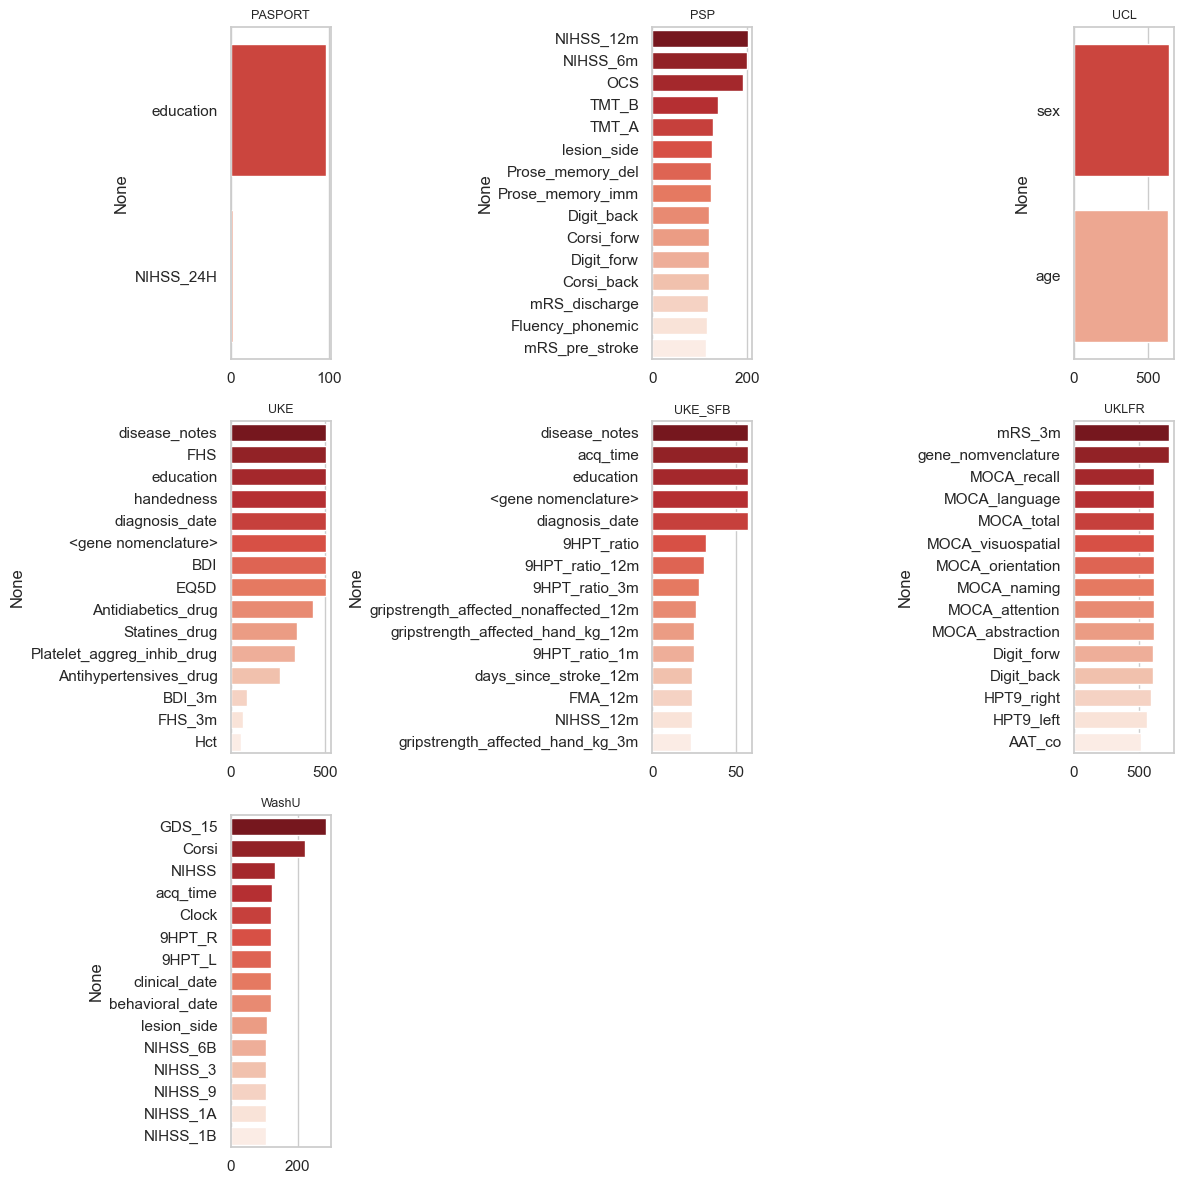

In [15]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(4, 4))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False).head(15)

    if missing.empty:
        ax.text(0.5, 0.5, "nessun missing", ha="center", va="center")
    else:
        sns.barplot(x=missing.values, y=missing.index, hue=missing.index, legend=False, palette="Reds_r", ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Conteggio Sani vs Malati

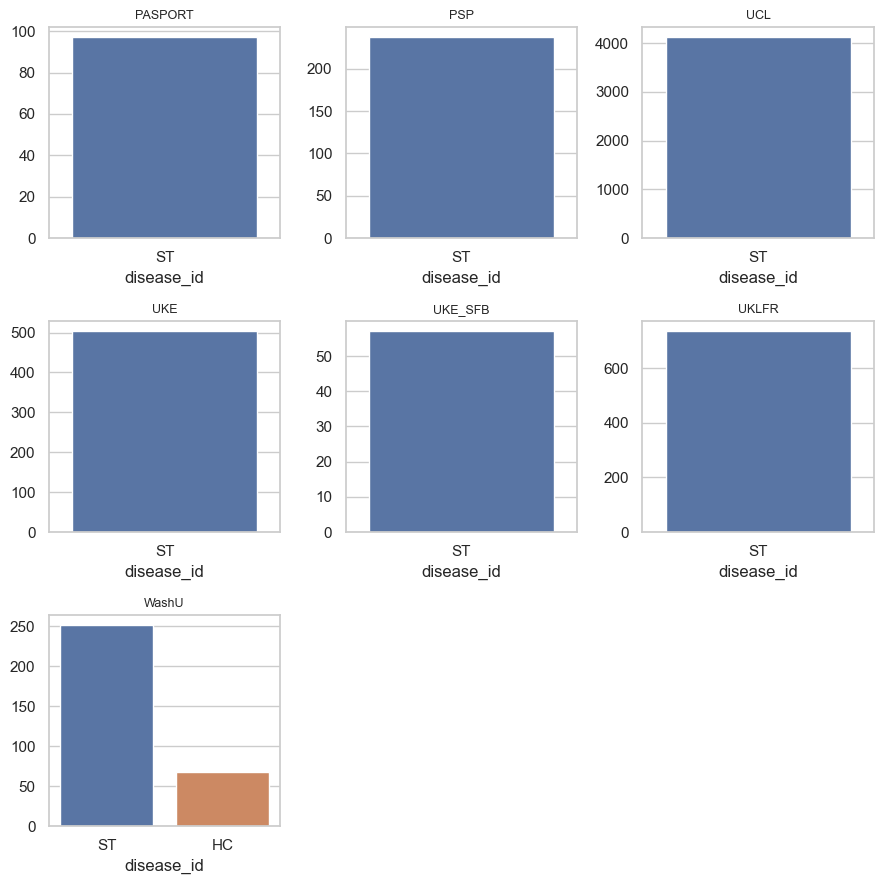

In [16]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3, 3))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    counts = df["disease_id"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Analisi Demografica


Età (per gruppo, se `disease_id` ha più di un valore) e sesso, ciascuna in una griglia separata.

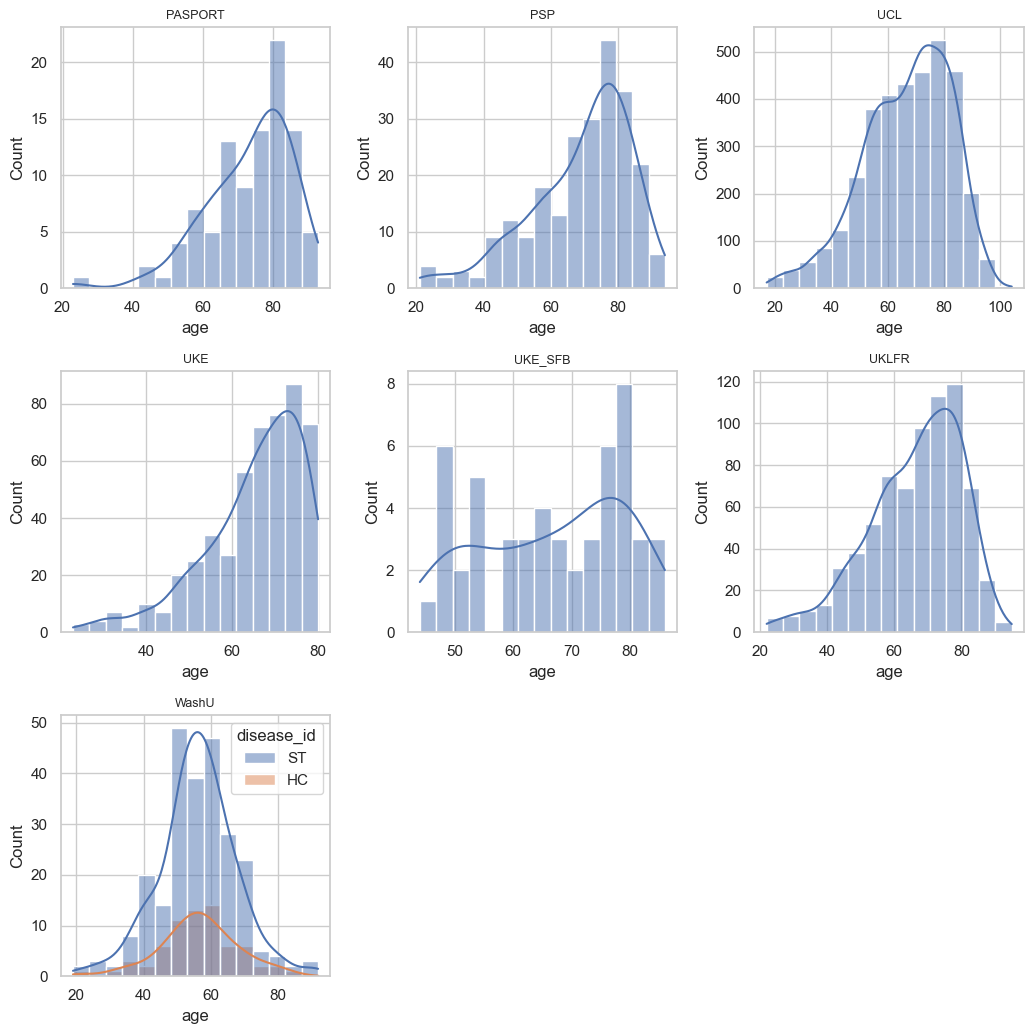

In [17]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3.5, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    hue_col = "disease_id" if df["disease_id"].nunique() > 1 else None
    sns.histplot(data=df, x="age", hue=hue_col, bins=15, kde=True, ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


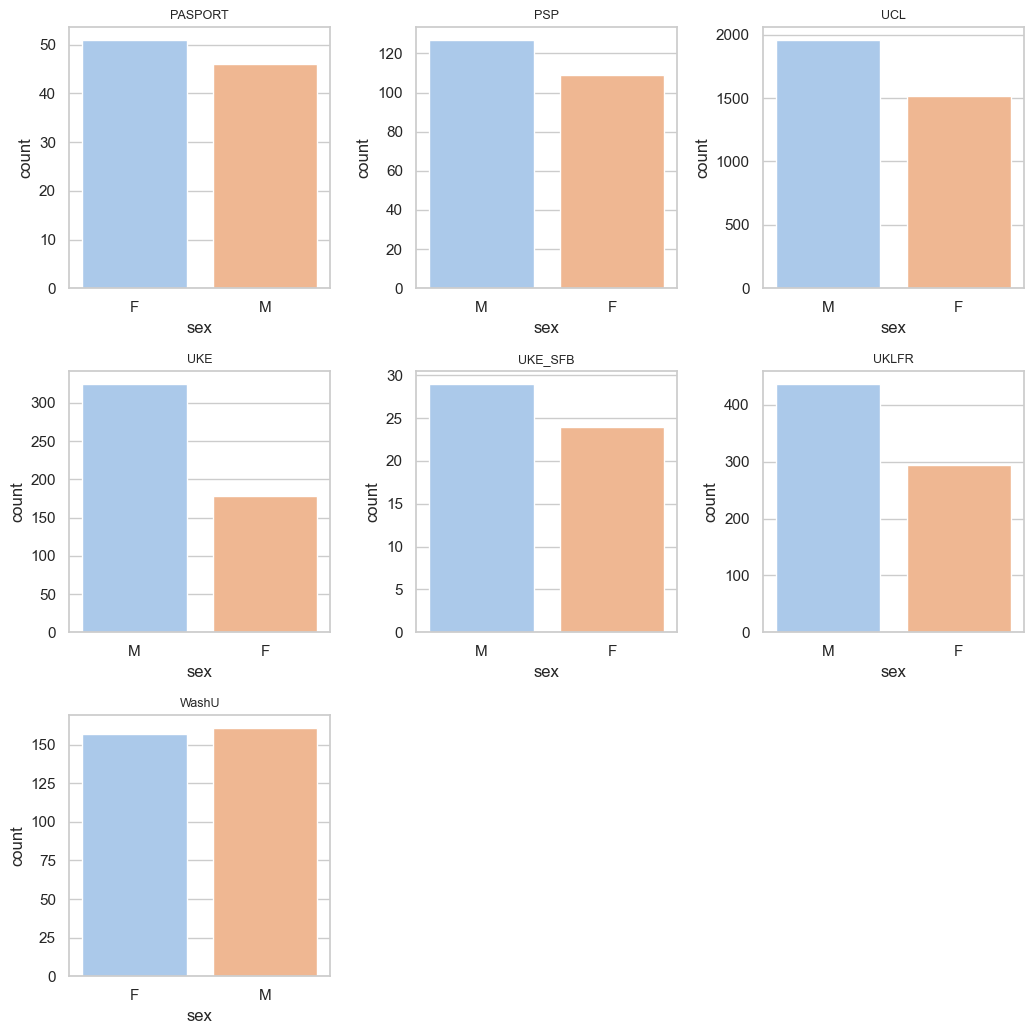

In [18]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3.5, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    if "sex" in df.columns:
        sns.countplot(data=df, x="sex", hue="sex", legend=False, palette="pastel", ax=ax)
    else:
        ax.text(0.5, 0.5, "sex non\ndisponibile", ha="center", va="center")
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Test Clinici e Comportamentali

Ogni dataset ha test diversi con nomi diversi: le colonne clinico/comportamentali sono rilevate automaticamente (numeriche, escluse quelle demografiche/anagrafiche/di laboratorio), poi per ognuna si mostra la % di soggetti con un valore valido (le migliori 20 per dataset).

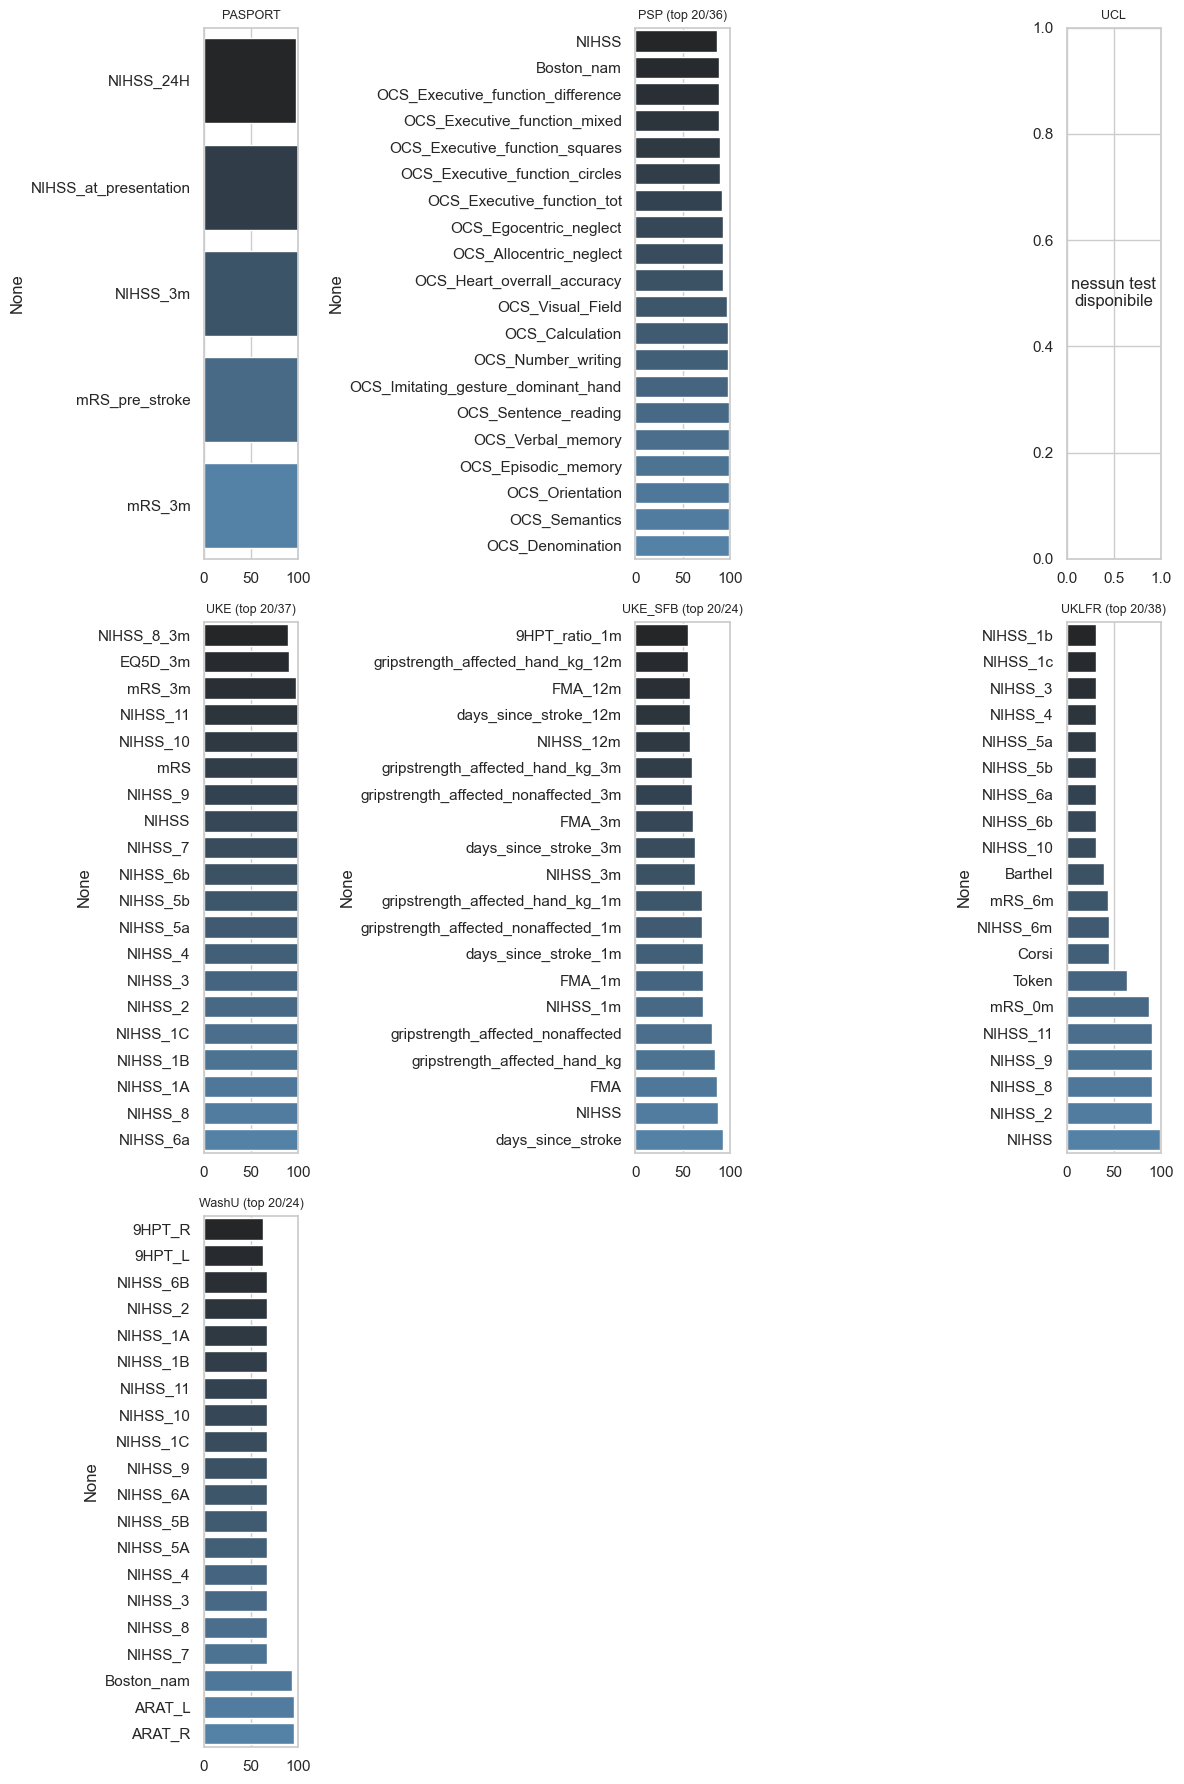

In [19]:
NON_CLINICAL_COLUMNS = {
    "participant_id", "original_id", "participant_id_dmp", "center_id", "disease_id", "disease_notes", "dataset",
    "age", "sex", "handedness", "education", "lesion_side", "lesion_type",
    "clinical_date", "behavioral_date", "behavioural_date", "acq_time", "acquisition_time", "diagnosis_date",
    "time_follow_up_(days)", "lesion_volume_ml", "<gene nomenclature>", "gene_nomvenclature", "codetrt",
    "Creatinine", "Hb", "Platelet_Count", "RBC_Count", "Serum_Glucose", "WBC_Count", "Hct", "INR", "aPTT",
    "Platelet_aggreg_inhib", "Anticoagulants", "Heparine", "LMWH", "Antihypertensives", "Statines", "Antidiabetics",
    "Arterial_hypertension", "Atrial_fibrillation", "TIA", "Ischemic_stroke", "Intracranial_haemorrhage",
    "Hypercholesterolemia", "Diabetes_mellitus_type_II", "Coagulation_disorder", "Gastro_intestinal_bleeding",
}

clinical_cols_by_dataset = {}
for name, df in datasets_tsv.items():
    clinical_cols_by_dataset[name] = [
        c for c in df.columns
        if c not in NON_CLINICAL_COLUMNS and pd.to_numeric(df[c], errors="coerce").notna().any()
    ]

fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(4, 6))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    cols = clinical_cols_by_dataset[name]
    if not cols:
        ax.text(0.5, 0.5, "nessun test\ndisponibile", ha="center", va="center")
        ax.set_title(name, fontsize=9)
        continue

    coverage = pd.Series({c: pd.to_numeric(df[c], errors="coerce").notna().mean() * 100 for c in cols}).sort_values()
    shown = coverage.tail(20)
    sns.barplot(x=shown.values, y=shown.index, hue=shown.index, legend=False, palette="dark:steelblue", ax=ax)
    ax.set_xlim(0, 100)
    ax.set_title(name if len(coverage) <= 20 else f"{name} (top 20/{len(coverage)})", fontsize=9)

plt.tight_layout()
plt.show();


### Gravità Clinica (NIHSS)

NIHSS alla baseline (colonna `NIHSS`), senza proxy da un'altra colonna. PASPORT e UCL non hanno `NIHSS` e restano `NaN` (in produzione `src/pipeline/enrich_metadata.py` applica per PASPORT la sostituzione registrata `NIHSS_at_presentation`, qui deliberatamente no). I controlli sani vengono esclusi.

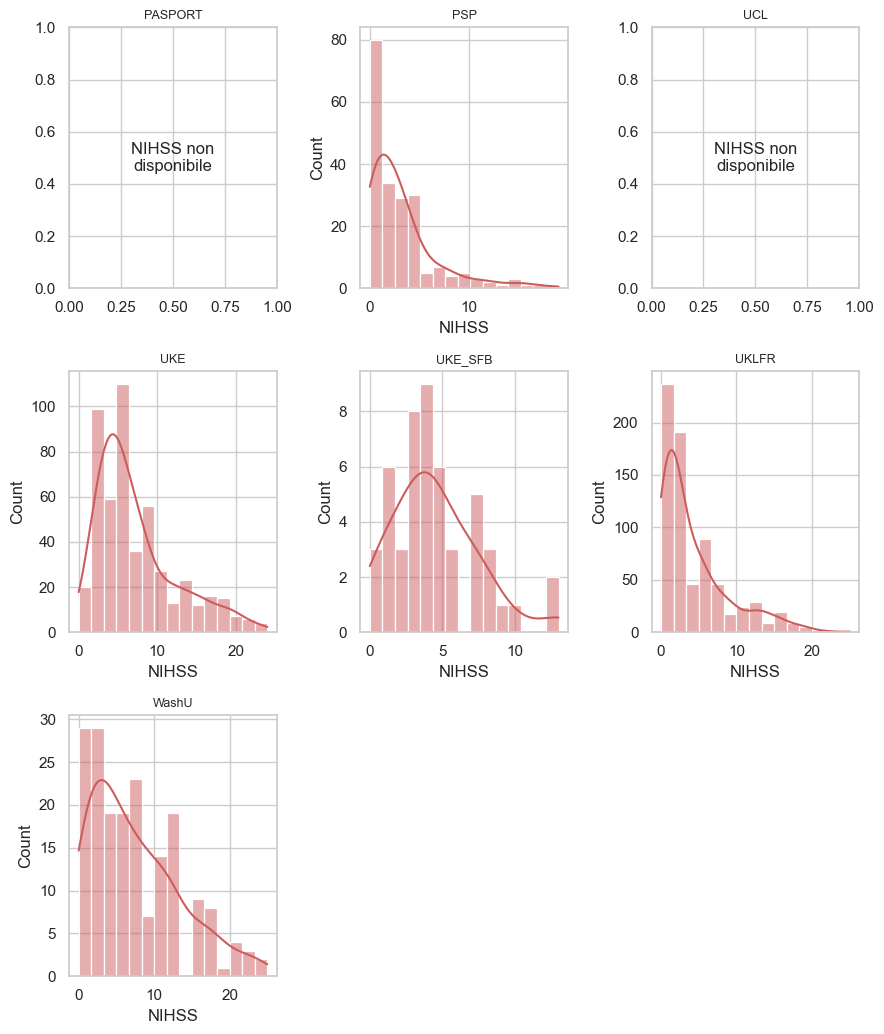

In [20]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    if "NIHSS" not in df.columns:
        ax.text(0.5, 0.5, "NIHSS non\ndisponibile", ha="center", va="center")
    else:
        df_st = df[df["disease_id"] == "ST"] if df["disease_id"].nunique() > 1 else df
        values = pd.to_numeric(df_st["NIHSS"], errors="coerce").dropna()
        if values.empty:
            ax.text(0.5, 0.5, "tutti mancanti", ha="center", va="center")
        else:
            sns.histplot(values, bins=15, color="indianred", kde=True, ax=ax)

    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Matrice di Correlazione

Correlazione di Pearson tra età, istruzione e le colonne cliniche rilevate sopra — per dataset, quindi ogni matrice ha le sue variabili.

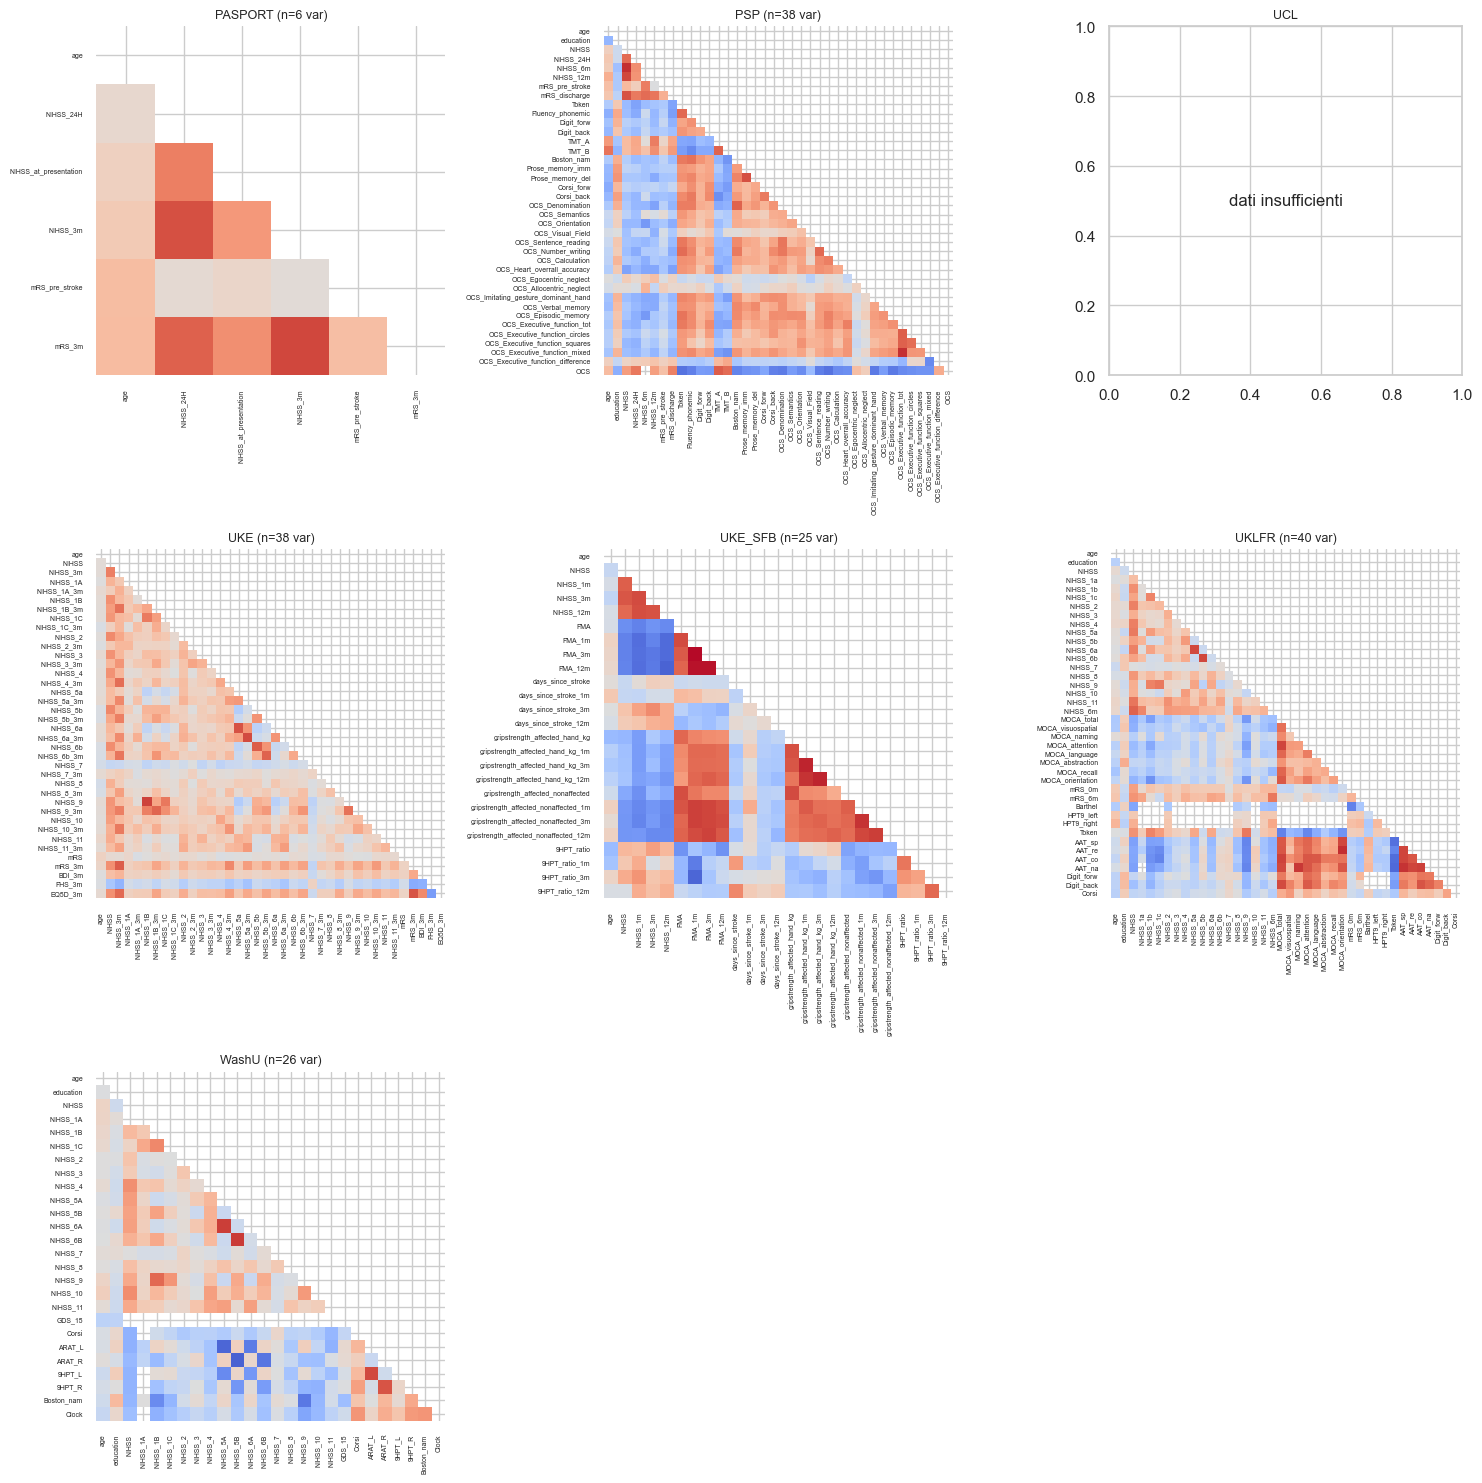

In [21]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(5, 5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    corr_cols = [c for c in ["age", "education"] if c in df.columns] + clinical_cols_by_dataset[name]
    numeric_df = df[corr_cols].apply(pd.to_numeric, errors="coerce") if corr_cols else pd.DataFrame()
    numeric_df = numeric_df.loc[:, numeric_df.notna().sum() > 1]

    if numeric_df.shape[1] < 2:
        ax.text(0.5, 0.5, "dati insufficienti", ha="center", va="center")
        ax.set_title(name, fontsize=9)
        continue

    corr = numeric_df.corr(method="pearson")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True,
                cbar=False, ax=ax, xticklabels=True, yticklabels=True)
    ax.set_title(f"{name} (n={numeric_df.shape[1]} var)", fontsize=9)
    ax.tick_params(axis="both", labelsize=5)

plt.tight_layout()
plt.show();
